## Exploratory Data analysis

### Roles to explore

In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Filter for only Indian Data science jobs

In [2]:
df_ind = df[df['job_country']=='India'].copy()

### Job location analysis

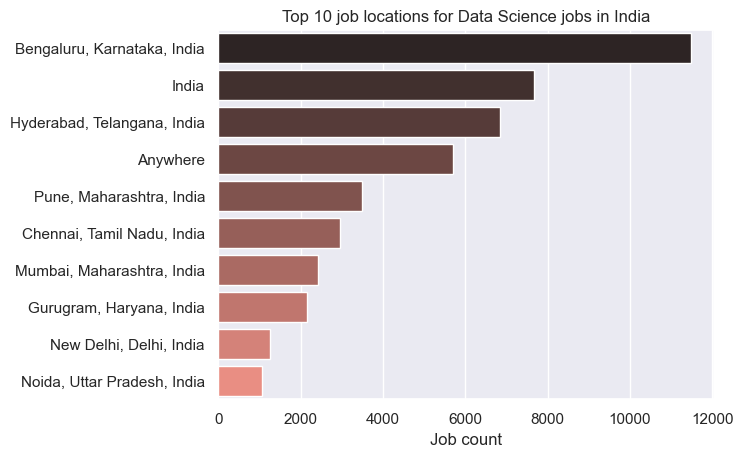

In [3]:
df_ind_loc = df_ind['job_location'].value_counts().head(10).to_frame()
sns.set_theme() ## default theme
sns.barplot(data=df_ind_loc, x='count', y=df_ind_loc.index, hue=df_ind_loc.index, palette='dark:salmon', legend=False)
plt.xlabel('Job count')
plt.ylabel('')
plt.title('Top 10 job locations for Data Science jobs in India', fontsize=12)
plt.show()

### WFH, Job Degree and Health insurance

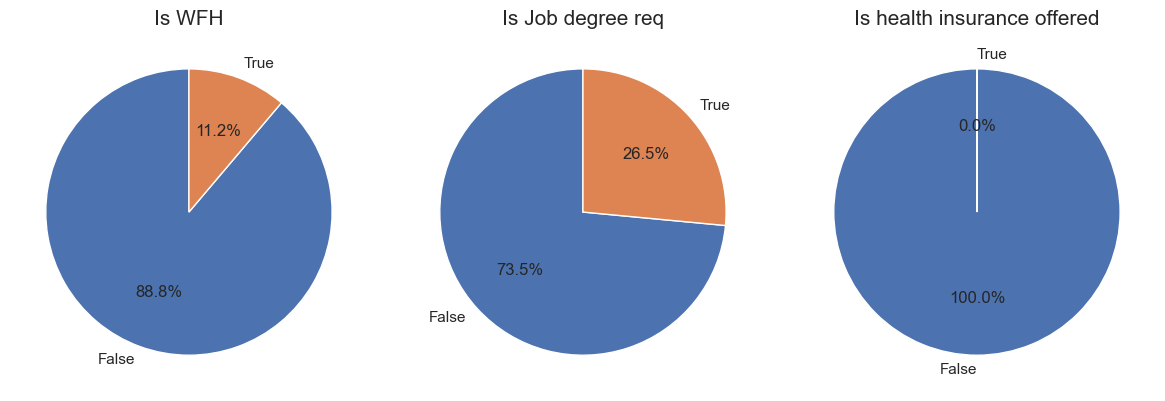

In [4]:
# Initialize a figure with 1 row and 3 columns for side-by-side comparison
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Mapping dataframe columns to user-friendly titles for the plots
dict_column = {
    'job_work_from_home': 'Is WFH',
    'job_no_degree_mention': 'Is Job degree req',
    'job_health_insurance': 'Is health insurance offered'
}

# Iterate through the dictionary to populate each subplot
for i, (column, title) in enumerate(dict_column.items()):
    # Calculate frequency of each category and plot as a pie chart
    ax[i].pie(
        df_ind[column].value_counts(), 
        startangle=90, 
        autopct='%1.1f%%',       # Display percentages with one decimal point
        labels=['False', 'True'] # Explicitly label the boolean categories
    )
    ax[i].set_title(title, fontsize=15)
# Adjust layout to prevent overlapping titles/labels and display the plot
fig.tight_layout()
plt.show()

### Which companies to apply for Data Science jobs?

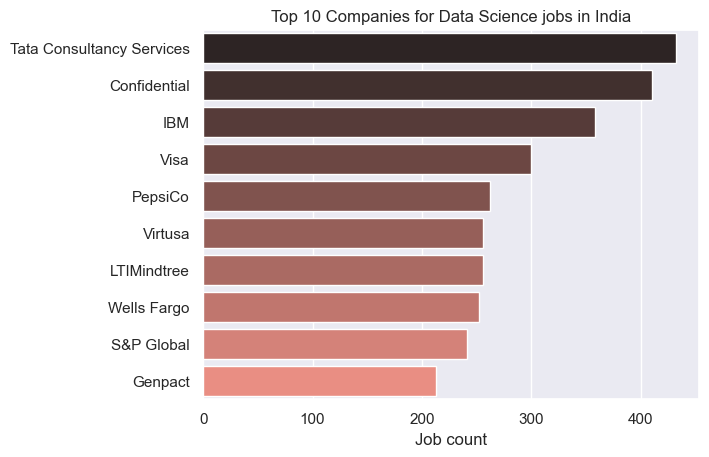

In [ ]:
df_ind_com = df_ind['company_name'].value_counts().head(10).to_frame()
sns.set_theme() ## default theme
sns.barplot(data=df_ind_com, x='count', y=df_ind_com.index, hue=df_ind_com.index, palette='dark:salmon', legend=False)
plt.xlabel('Job count')
plt.ylabel('')
plt.title('Top 10 Companies for Data Science jobs in India', fontsize=12)
plt.show()

### Job Trend

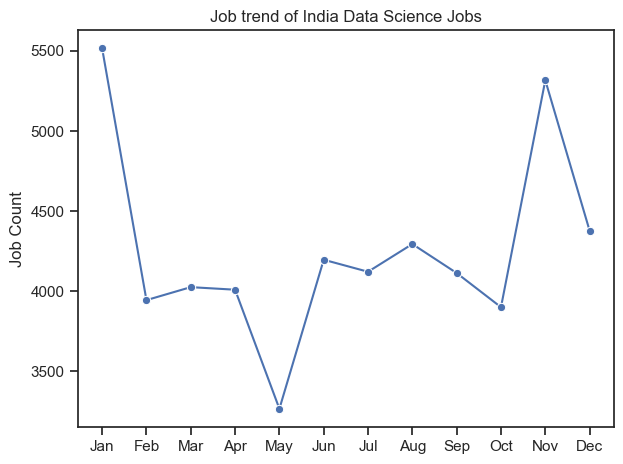

,Job Count
job_posted_month,
Jan,5516
Feb,3945
Mar,4026
Apr,4010
May,3267
Jun,4197
Jul,4122
Aug,4295
Sep,4114


In [59]:
df_ind['job_posted_month_no'] = df_ind['job_posted_date'].dt.month
# df_ind_pivot = df_ind.pivot_table(index='job_posted_month_no', aggfunc='size')
df_ind_piv = df_ind.pivot_table(index='job_posted_month_no', aggfunc='size').reset_index()
df_ind_piv = df_ind_piv.rename(columns={0: 'Job Count'})

df_ind_piv['job_posted_month'] = df_ind_piv['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_ind_piv = df_ind_piv.set_index('job_posted_month')
df_ind_piv = df_ind_piv.drop(columns='job_posted_month_no')

sns.set_theme(style='ticks') ## default theme
sns.lineplot(data=df_ind_piv, legend=False,markers='o')
plt.xlabel('')
plt.ylabel('Job Count')
plt.title('Job trend of India Data Science Jobs')


plt.tight_layout()
plt.show()
df_ind_piv